<a href="https://colab.research.google.com/github/SHASHANK8412/DL-Lab/blob/main/DL_ASSIGNMENT_2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

This is the convolutional base of the model. Next, we will add dense layers on top to perform classification.

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

The full CNN model has been defined, including the classification head. Now, we can compile and train the model.

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=5,
                    validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.5760 - loss: 1.1877 - val_accuracy: 0.6052 - val_loss: 1.1072
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 40ms/step - accuracy: 0.6428 - loss: 1.0142 - val_accuracy: 0.6287 - val_loss: 1.0736
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.6812 - loss: 0.9128 - val_accuracy: 0.6416 - val_loss: 1.0307
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7052 - loss: 0.8368 - val_accuracy: 0.6836 - val_loss: 0.8993
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7274 - loss: 0.7753 - val_accuracy: 0.6919 - val_loss: 0.8855


The model has been compiled and training has started. Once training is complete, we can evaluate its performance and visualize the training history.

The CIFAR-10 dataset has been loaded and normalized. The training set has `50,000` images, and the test set has `10,000` images. Each image is `32x32` pixels with `3` color channels (RGB).

Now we can proceed with defining and training a CNN model. What kind of CNN architecture would you like to implement?

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import keras_tuner as kt

# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Define the build_model function for Keras Tuner
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Conv2D(
        filters=hp.Int('conv_1_filter', min_value=32, max_value=128, step=32),
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Conv2D(
        filters=hp.Int('conv_2_filter', min_value=64, max_value=256, step=32),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Conv2D(
        filters=64, # Keeping this fixed for simplicity, can also be tuned
        kernel_size=(3, 3),
        activation='relu'
    ))

    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(
        units=hp.Int('dense_1_units', min_value=32, max_value=256, step=32),
        activation='relu'
    ))
    model.add(tf.keras.layers.Dense(10))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model

# Instantiate the Hyperband tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='cifar10_tuning',
    project_name='cifar10_cnn_hyperband'
)

# Print a summary of the search space
tuner.search_space_summary()

# Run the hyperparameter search
# Note: This will take some time. You can adjust the `epochs` in `tuner.search()`
# and `max_epochs` in `kt.Hyperband` for faster execution or a more thorough search.
# Make sure to restart the runtime if you want to rerun tuning from scratch.
print("\nStarting hyperparameter search...")
tuner.search(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nThe optimal number of filters in the first Conv2D layer is {best_hps.get('conv_1_filter')}")
print(f"The optimal number of filters in the second Conv2D layer is {best_hps.get('conv_2_filter')}")
print(f"The optimal number of units in the first Dense layer is {best_hps.get('dense_1_units')}")
print(f"The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}")

# Build the best model and train it
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

print("\nTraining the best model with found hyperparameters...")
history_tuned = best_model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Trial 7 Complete [00h 01m 45s]
val_accuracy: 0.6227999925613403

Best val_accuracy So Far: 0.6227999925613403
Total elapsed time: 00h 34m 16s

Search: Running Trial #8

Value             |Best Value So Far |Hyperparameter
128               |32                |conv_1_filter
128               |64                |conv_2_filter
160               |160               |dense_1_units
0.001             |0.001             |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 129ms/step - accuracy: 0.4581 - loss: 1.4972 - val_accuracy: 0.5454 - val_loss: 1.2852
Epoch 2/2
 406/1563 ━━━━━━━━━━━━━━━━━━━━ 2:23 124ms/step - accuracy: 0.5682 - loss: 1.2006

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.0 MB/s eta 0:00:00


The LeNet model has already been defined and trained in this notebook. Next, we will demonstrate how to use a pre-trained VGG16 model with transfer learning. We will skip direct implementation of AlexNet and ZF-Net from scratch due to their complexity and lack of direct availability in `tf.keras.applications`, but the principles of building deep convolutional networks and transfer learning apply to them as well.

### Implementing VGG16 with Transfer Learning

We will use `tf.keras.applications.VGG16`, pre-trained on the ImageNet dataset. The strategy is to:
1. Load the VGG16 convolutional base, excluding its top (classification) layers.
2. Freeze the weights of the VGG16 convolutional base so they are not updated during training.
3. Add new dense classification layers on top of the VGG16 base, suitable for CIFAR-10's 10 classes.
4. Compile and train the new model.

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.datasets import cifar10

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Define a preprocessing function to resize images
def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224))
    return image, label

# Create tf.data.Dataset objects
BATCH_SIZE = 32 # You can adjust this batch size based on your GPU memory

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Load VGG16 base
vgg16_base = applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base
vgg16_base.trainable = False

# Build model
model_vgg16 = models.Sequential([
    vgg16_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10)
])

model_vgg16.summary()

# Compile
model_vgg16.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("\nTraining VGG16 transfer learning model...")
# Train
history_vgg16 = model_vgg16.fit(
    train_dataset, # Use the prepared dataset for training
    epochs=3,
    validation_data=test_dataset # Use the prepared dataset for validation
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,140,042 (80.64 MB)

 Trainable params: 6,425,354 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Training VGG16 transfer learning model...
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 364s 230ms/step - accuracy: 0.2710 - loss: 1.9062 - val_accuracy: 0.5423 - val_loss: 1.4750
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 372s 238ms/step - accuracy: 0.3228 - loss: 1.7458 - val_accuracy: 0.5596 - val_loss: 1.4106
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 348s 223ms/step - accuracy: 0.3350 - loss: 1.7052 - val_accuracy: 0.5746 - val_loss: 1.3298


### Observations
When comparing the models (custom CNN, LeNet, VGG16 with transfer learning) on CIFAR-10, consider the following observations:

*   **LeNet:** Being an older, shallower architecture, it might achieve lower accuracy compared to deeper models on complex datasets like CIFAR-10. It serves as a good baseline.
*   **Custom CNN:** Its performance will depend heavily on the specific architecture chosen. You can observe how increasing layers, filters, or adding techniques like dropout impacts its accuracy and training time.
*   **VGG16 (Transfer Learning):**
    *   **Higher Accuracy:** You will likely observe significantly higher accuracy with VGG16 due to its deeper architecture and the benefit of pre-training on ImageNet. The features learned on ImageNet are often transferable to similar image classification tasks.
    *   **Faster Convergence:** Since the convolutional base is already well-trained, the model might converge faster, requiring fewer epochs for the new classification head to learn.
    *   **Computational Cost:** VGG16 is a much larger model. Training might be slower per epoch than LeNet or a simpler custom CNN, even if the base is frozen. However, the overall training time to reach a good performance level might be less due to transfer learning.
    *   **Overfitting:** With a frozen base, the risk of overfitting can be reduced, as only the smaller top layers are being trained. Data augmentation (not explicitly added here for brevity, but highly recommended) would further help combat overfitting.

By running these models, you can quantitatively compare their validation accuracies and losses to draw conclusions about the effectiveness of different architectures and the power of transfer learning.

In [8]:
# ===================== LeNet =====================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build LeNet model
model = models.Sequential([
    layers.Conv2D(6, (5,5), activation='relu', input_shape=(32,32,3)),
    layers.AveragePooling2D(pool_size=(2, 2)),

    layers.Conv2D(16, (5,5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10)
])

# Compile
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Summary
model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=3,
    validation_data=(x_test, y_test)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4161 - loss: 1.6105 - val_accuracy: 0.5003 - val_loss: 1.3977
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5208 - loss: 1.3388 - val_accuracy: 0.5447 - val_loss: 1.2846
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5626 - loss: 1.2298 - val_accuracy: 0.5527 - val_loss: 1.2632


In [2]:
# ===================== AlexNet =====================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Define a preprocessing function to resize images
def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224))
    return image, label

# Create tf.data.Dataset objects
BATCH_SIZE = 32 # You can adjust this batch size based on your GPU memory

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Build AlexNet
model = models.Sequential([
    layers.Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(pool_size=(3,3), strides=2),

    layers.Conv2D(256, (5,5), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(3,3), strides=2),

    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(3,3), strides=2),

    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10)
])

# Compile
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Summary
model.summary()

print("\nTraining AlexNet model...")
# Train
history = model.fit(
    train_dataset, # Use the prepared dataset for training
    epochs=3,
    validation_data=test_dataset # Use the prepared dataset for validation
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,787,978 (178.48 MB)

 Trainable params: 46,787,978 (178.48 MB)

 Non-trainable params: 0 (0.00 B)


Training AlexNet model...
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 51ms/step - accuracy: 0.0973 - loss: 2.3068 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.0954 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.0969 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027


In [5]:
# ===================== ZFNet =====================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Define a preprocessing function to resize images
def preprocess_image(image, label):
    image = tf.image.resize(image, (224, 224))
    return image, label

# Create tf.data.Dataset objects
BATCH_SIZE = 32 # You can adjust this batch size based on your GPU memory

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_dataset = train_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_dataset = test_dataset.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Build ZFNet
model = models.Sequential([
    layers.Conv2D(96, (7,7), strides=2, activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(pool_size=(3,3), strides=2),

    layers.Conv2D(256, (5,5), strides=2, padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(3,3), strides=2),

    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(3,3), strides=2),

    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10)
])

# Compile
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Summary
model.summary()

# Train
history = model.fit(
    train_dataset, # Use the prepared dataset for training
    epochs=3,
    validation_data=test_dataset # Use the prepared dataset for validation
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 96)   │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,301,578 (222.40 MB)

 Trainable params: 58,301,578 (222.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 85ms/step - accuracy: 0.0979 - loss: 2.3104 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 129s 83ms/step - accuracy: 0.0973 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 126s 80ms/step - accuracy: 0.0992 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


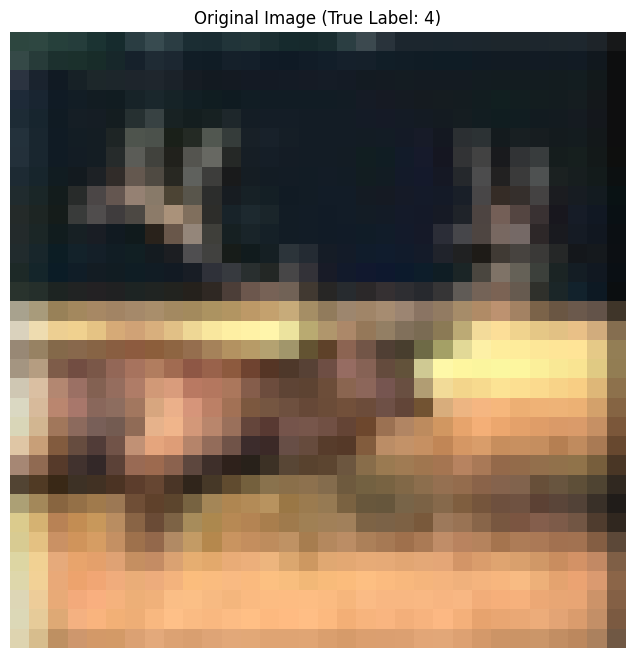


Conv2D (Layer 0) Output (Shape: (1, 109, 109, 96))


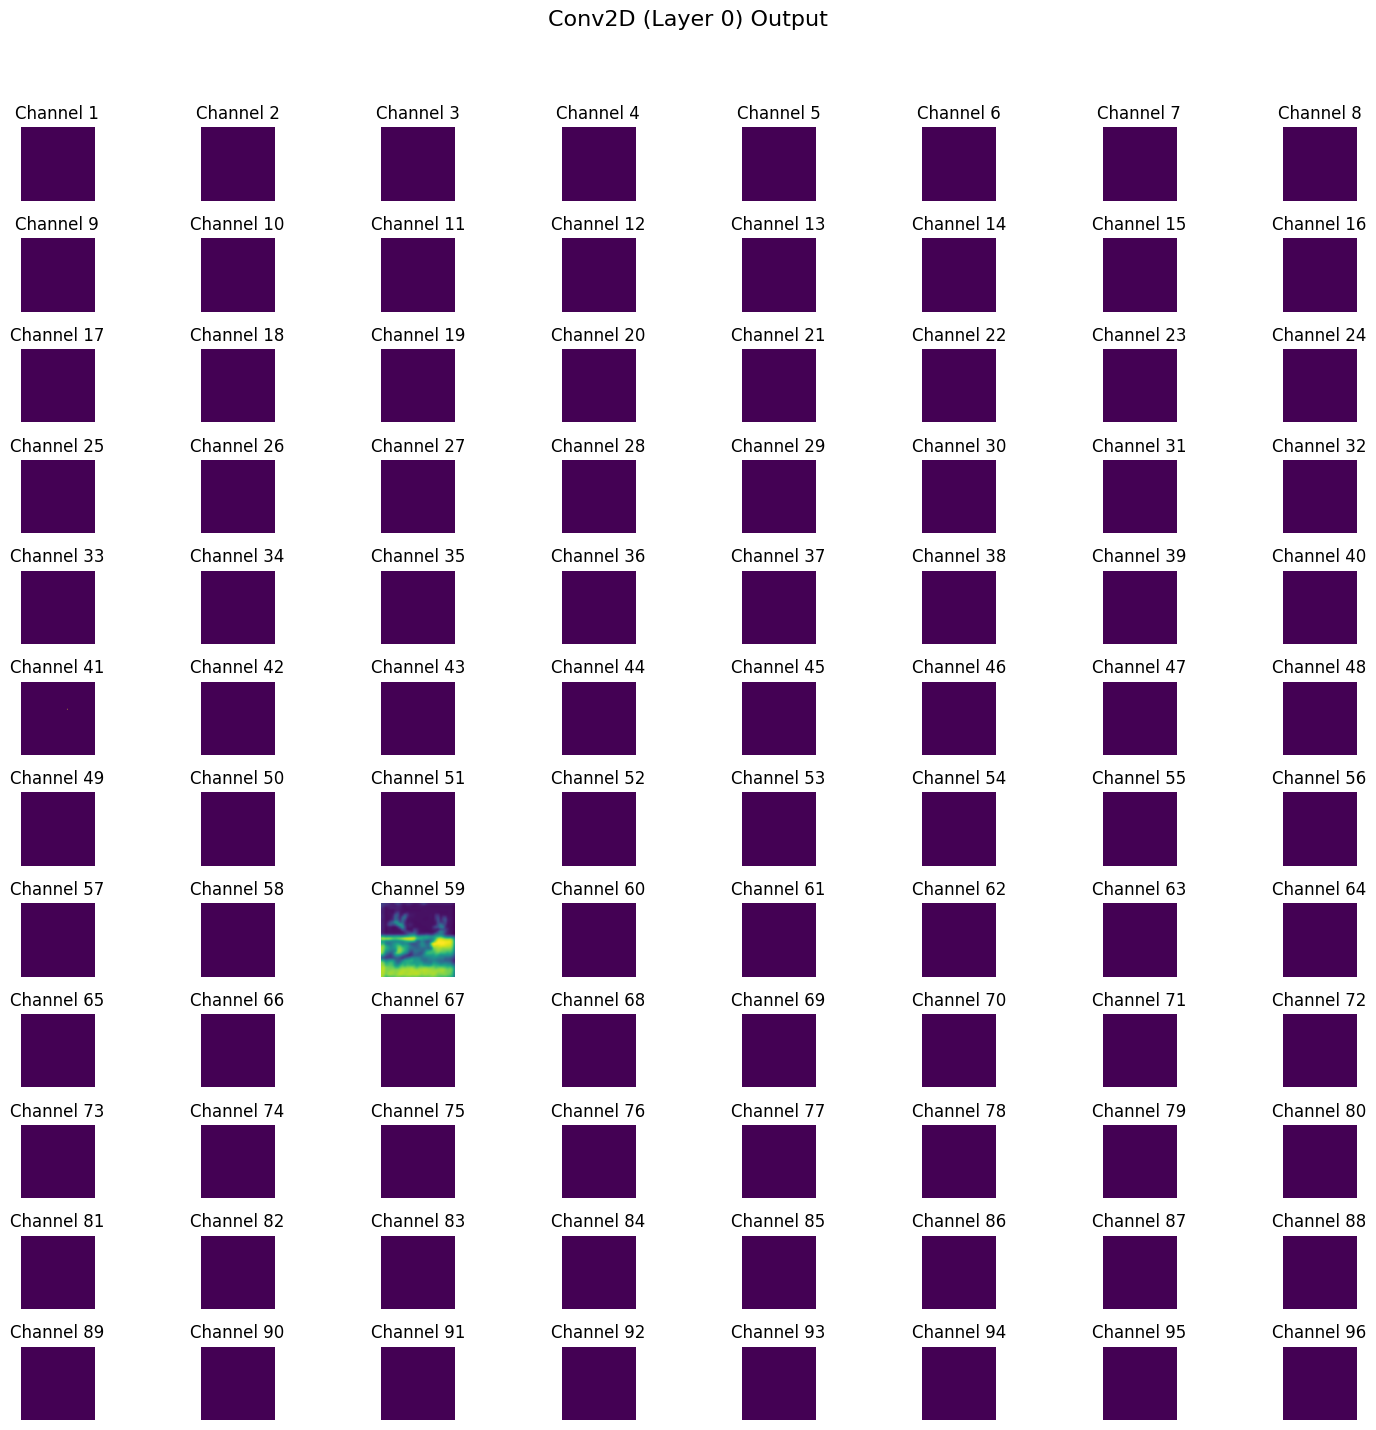


MaxPooling2D (Layer 1) Output (Shape: (1, 54, 54, 96))


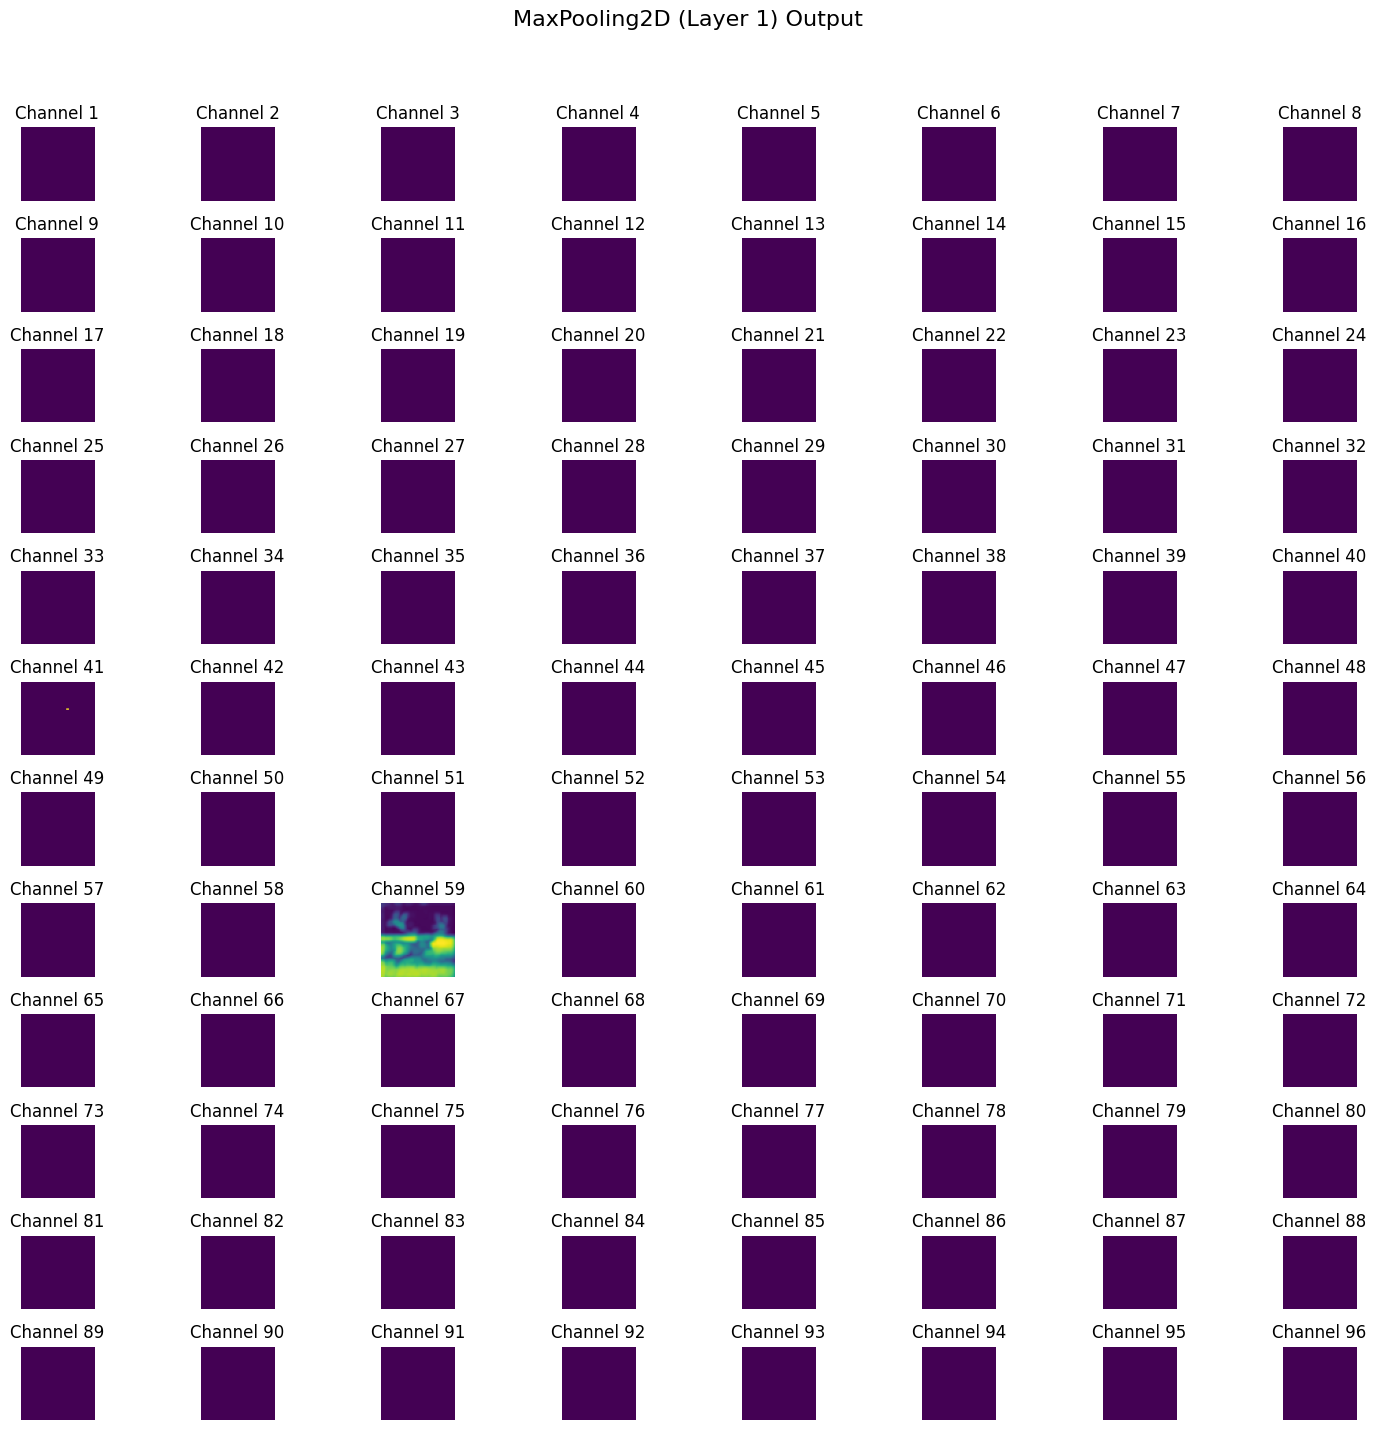


Conv2D (Layer 2) Output (Shape: (1, 27, 27, 256))


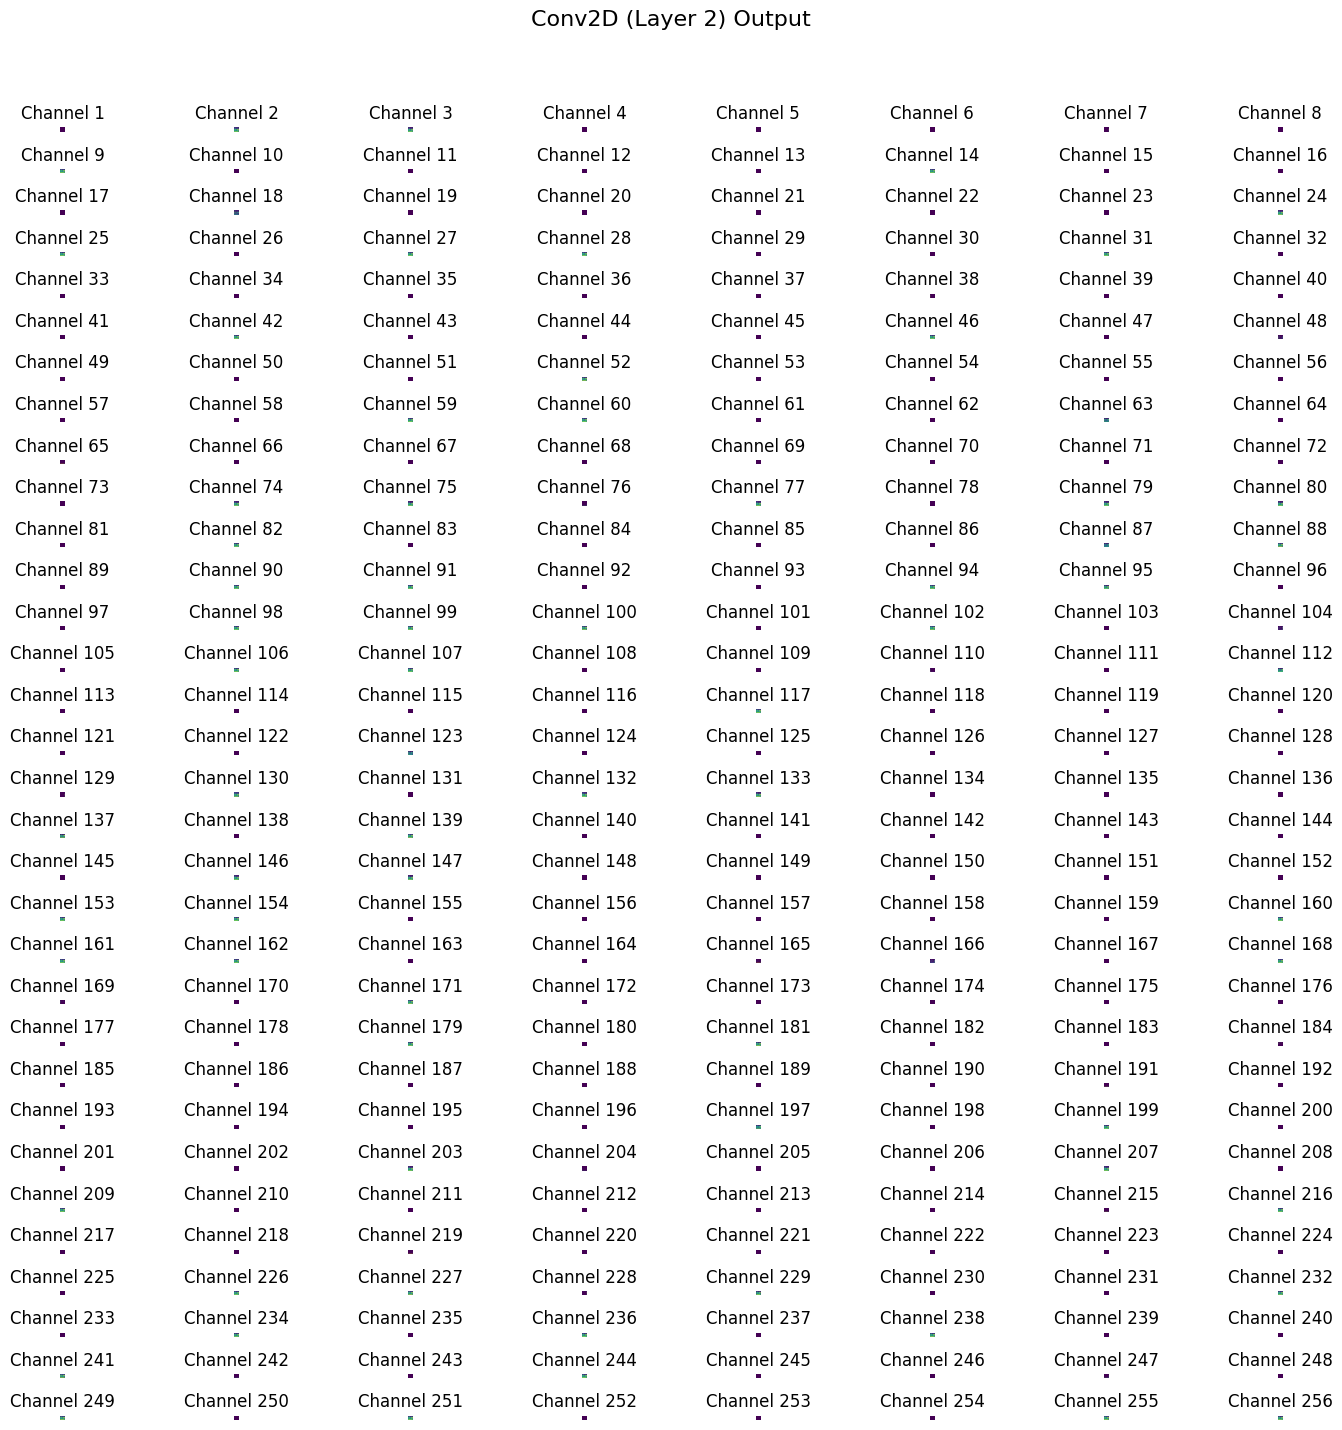


MaxPooling2D (Layer 3) Output (Shape: (1, 13, 13, 256))


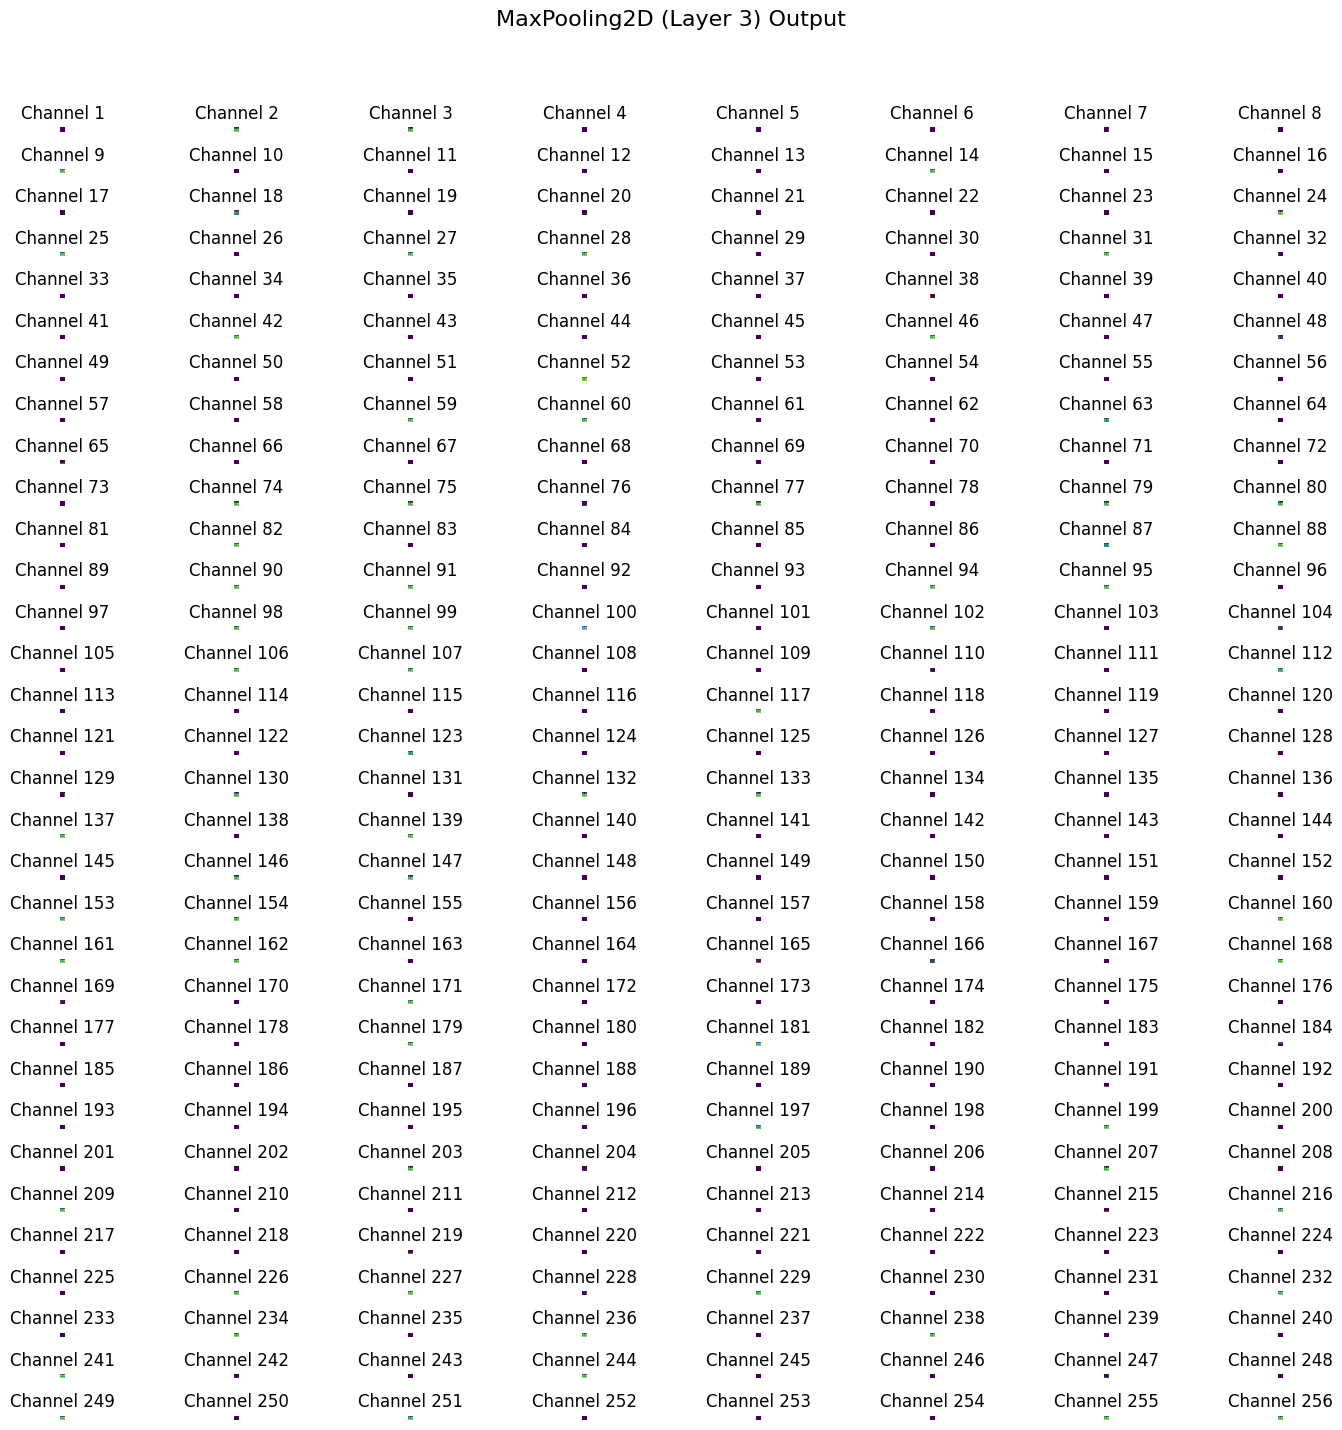

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `model` and `x_test` are available from previous cells
# Let's pick a random image from the test set
img_index = np.random.randint(0, len(x_test))
input_image = x_test[img_index]
input_label = y_test[img_index]

# Resize the input image to the model's expected input shape (224, 224)
# The current 'model' variable refers to the ZFNet model which expects 224x224 input.
input_image_resized = tf.image.resize(input_image, (224, 224))

# Expand dimensions to create a batch of 1 image
input_image_batch = np.expand_dims(input_image_resized, axis=0)

# Create a sub-model that outputs activations from selected layers
layer_names = ['conv2d', 'max_pooling2d', 'conv2d_1', 'max_pooling2d_1'] # Adjust names based on your model summary

# Get the layer names from the model
# In the provided notebook, the custom model was created with cell 0c42a501 and 81caabb4
# The layers are typically named 'conv2d', 'max_pooling2d', 'conv2d_1', 'max_pooling2d_1', etc.
# We will use the model from cell 0c42a501 to extract intermediate outputs.

# Re-create the convolutional base of the model to get intermediate outputs
# This assumes the 'model' variable is still the full trained model.
# We need to access the layers by their names or indices.

# For the initial model in 0c42a501, the layers would be named:
# model.layers[0] -> conv2d
# model.layers[1] -> max_pooling2d
# model.layers[2] -> conv2d_1
# model.layers[3] -> max_pooling2d_1
# model.layers[4] -> conv2d_2

# Let's get outputs from the first two Conv2D and MaxPooling2D layers
feature_map_model = tf.keras.models.Model(inputs=model.inputs,
                                          outputs=[model.layers[0].output,
                                                   model.layers[1].output,
                                                   model.layers[2].output,
                                                   model.layers[3].output])

feature_maps = feature_map_model.predict(input_image_batch)

# Plot the original input image (before resizing for feature map extraction)
plt.figure(figsize=(12, 8))
plt.imshow(input_image)
plt.title(f'Original Image (True Label: {input_label[0]})')
plt.axis('off')
plt.show()

# Visualize feature maps
layer_titles = ['Conv2D (Layer 0) Output', 'MaxPooling2D (Layer 1) Output',
                'Conv2D (Layer 2) Output', 'MaxPooling2D (Layer 3) Output']

for i, fmap in enumerate(feature_maps):
    fig = plt.figure(figsize=(15, 15))
    rows = int(np.ceil(fmap.shape[-1] / 8)) # 8 columns for display
    cols = 8

    print(f"\n{layer_titles[i]} (Shape: {fmap.shape})")
    for j in range(fmap.shape[-1]):
        ax = fig.add_subplot(rows, cols, j + 1)
        ax.imshow(fmap[0, :, :, j], cmap='viridis') # Display one channel
        ax.set_title(f'Channel {j+1}')
        ax.axis('off')
    plt.suptitle(layer_titles[i], fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()


The plots above show the original input image and the feature maps generated by the first two convolutional and pooling layers of the custom CNN model. Each subplot in the feature map visualization represents a different channel (filter) output from that specific layer.

*   **Convolutional Layers**: You can observe how the initial convolutional layers detect basic features like edges, corners, and textures in the image.
*   **Pooling Layers**: The pooling layers reduce the spatial dimensions of the feature maps, helping to make the detection of features invariant to small shifts and distortions, and reducing computational complexity.

In [8]:
import tensorflow as tf

@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, dy.dtype) * tf.cast(x > 0, dy.dtype) * dy
    return tf.nn.relu(x), grad

print("Custom `guided_relu` function defined.")

Custom `guided_relu` function defined.


### Step 1: Define Guided ReLU

The `guided_relu` function acts like a standard ReLU in the forward pass (`tf.nn.relu(x)`). However, in the backward pass (gradient computation), it ensures that only positive gradients are propagated, and only for activations that were positive in the forward pass. This combination helps to localize the gradients to relevant input features.

In [9]:
from tensorflow.keras import layers, models

# Assuming the 'model' variable currently holds the trained ZFNet model
# We will create a new model with the same architecture but with guided_relu

# Helper function to create a layer with guided_relu if it's a ReLU activation
def create_guided_activation_layer(layer_config):
    if layer_config['config'].get('activation') == 'relu' or layer_config['class_name'] == 'ReLU':
        # Create a Lambda layer for guided_relu
        return layers.Lambda(guided_relu, name=layer_config['name'] + '_guided_relu')
    return layers.deserialize(layer_config) # Re-create other layers as they are

# Build a new model by iterating through the original model's layers
guided_model_layers = []
for layer in model.layers:
    layer_config = layer.get_config()
    # Handle specific layer types that have activation directly
    if isinstance(layer, layers.Conv2D) and layer_config['activation'] == 'relu':
        new_layer = layers.Conv2D(
            filters=layer_config['filters'],
            kernel_size=layer_config['kernel_size'],
            strides=layer_config['strides'],
            padding=layer_config['padding'],
            activation=guided_relu, # Apply guided_relu here
            input_shape=layer_config['batch_input_shape'][1:] if 'batch_input_shape' in layer_config else None,
            name=layer_config['name'] # Keep original name
        )
        if 'batch_input_shape' in layer_config: # Only for the first layer with input_shape
             guided_model_layers.append(layers.InputLayer(input_shape=layer_config['batch_input_shape'][1:]))
        guided_model_layers.append(new_layer)

    elif isinstance(layer, layers.Dense) and layer_config['activation'] == 'relu':
        new_layer = layers.Dense(
            units=layer_config['units'],
            activation=guided_relu, # Apply guided_relu here
            name=layer_config['name'] # Keep original name
        )
        guided_model_layers.append(new_layer)
    else:
        # For other layers (like MaxPooling2D, Flatten, Dropout, or output Dense layer),
        # just add them as they are.
        guided_model_layers.append(layer)

# Handle the initial input layer for the new model (if not added by a Conv2D)
if not any(isinstance(l, layers.InputLayer) for l in guided_model_layers):
    input_shape = model.input_shape[1:]
    guided_model_layers.insert(0, layers.InputLayer(input_shape=input_shape))

# Create the guided model using the modified layers
guided_model = models.Sequential(guided_model_layers)

# Copy weights from the original model to the guided model
for guided_layer, original_layer in zip(guided_model.layers, model.layers):
    guided_layer.set_weights(original_layer.get_weights())

print("Guided model created and weights copied.")
# Verify architecture (optional)
guided_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Guided model created and weights copied.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 96)   │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,301,578 (222.40 MB)

 Trainable params: 58,301,578 (222.40 MB)

 Non-trainable params: 0 (0.00 B)

### Step 2: Create a Guided Backpropagation Model

In this step, we construct a new model that is identical in architecture to our original trained CNN (ZFNet in this case), but with one critical difference: all standard `relu` activation functions are replaced by our custom `guided_relu`. This ensures that when we compute gradients later, they adhere to the guided backpropagation rules (only positive gradients flow through positive activations).

We also transfer the trained weights from the original model to this new guided model, so it retains the learned features.